<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Train-Test Split and Cross-Validation Lab 


## Review of Train/Test Validation Methods

We've discussed overfitting, underfitting, and how to validate the "generalizeability" of your models by testing them on unseen data. 

In this lab you'll practice two related validation methods: 
1. **train/test split**
2. **k-fold cross-validation**

Train/test split and k-fold cross-validation both serve two useful purposes:
- We prevent overfitting by not using all the data, and
- We retain some remaining data to evaluate our model.

In the case of cross-validation, the model fitting and evaluation is performed multiple times on different train/test splits of the data.

Ultimately we can use the training/test validation framework to compare multiple models on the same dataset. This could be comparisons of two linear models, or of completely different models on the same data.


## Instructions

For your independent practice, fit **three different models** on the Boston Housing Data. For example, you could pick three different subsets of variables, one or more polynomial models, or any other model that you like. 

**Start with train/test split validation:**
* Fix a testing/training split of the data.
* Train each of your models on the training data.
* Evaluate each of the models on the testing data.
* Rank the models by how well they score on the testing data set.

**Then try k-fold cross-validation:**
* Perform a k-fold cross-validation and use the cross-validation scores to compare your models. Did this change your rankings?
* Try a few different k-splits of the data for the same models.

If you're interested, try a variety of response variables. We start with **PRICE** (the `.target` attribute from the data set load method).

In [1]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score

from sklearn import datasets

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.style.use('fivethirtyeight')


In [2]:
# Load the Boston Housing dataset
df = pd.read_csv('BostonHousing2.csv')
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# No code here please


In [4]:
# your code here
# what is the shape of the dataframe?
df.shape


(506, 14)

In [5]:
# No code here please

### 1) Clean up any data problems.

Fix any problems with the data, if applicable.

In [6]:
# your code here
# any missing data?
df.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [7]:
# No code here please

# There is no missing data as per the result

In [8]:
# your code here
# Get overview of your data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
# No code here please



In [10]:
# your code here
# Get the max for each column
df.max()


CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [11]:
# No code here please


In [12]:
# your code here
# Get the min for each column
df.min()


CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

In [13]:
# No code here please


### 2) Select 3–4 variables with your data set on which to perform a 50-50 train/test split.

- Use scikit-learn.
- Score and plot your predictions.

In [14]:
corr = df.corr()
corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


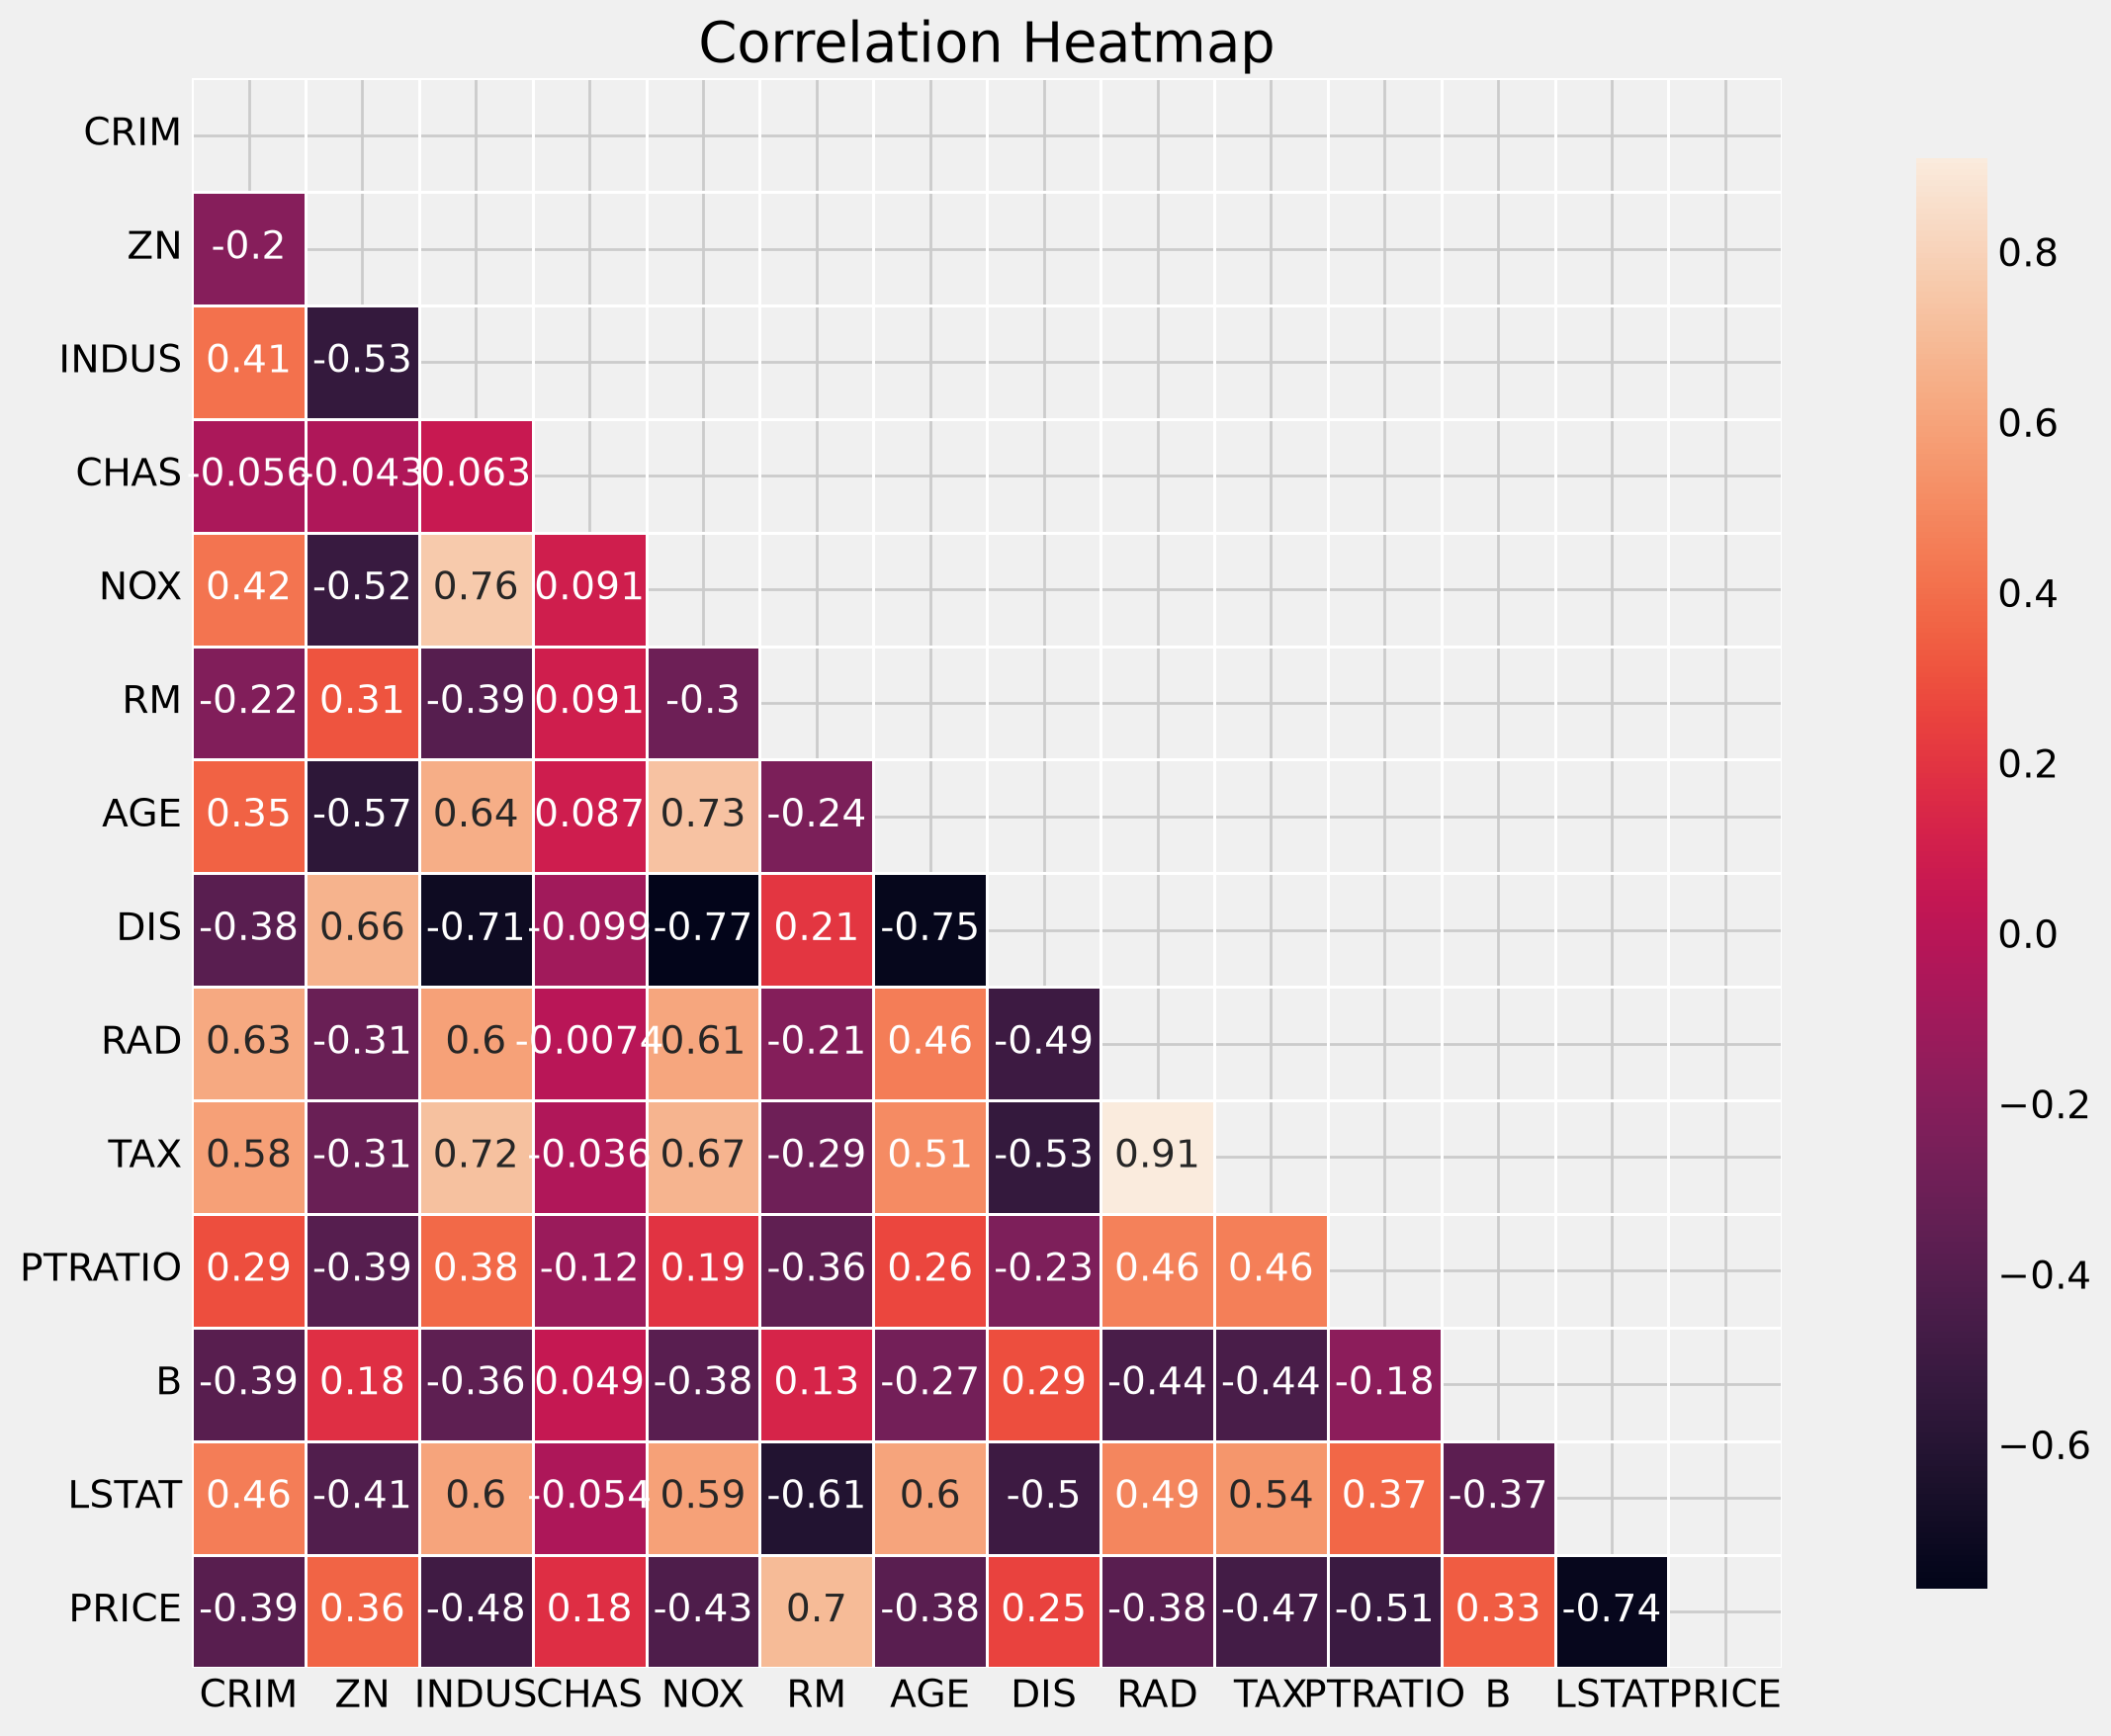

In [15]:
# your code here
# get correlation in corr and do a coorelation heatmap.
# Features (3-4 variables)
X = df[['RM', 'ZN', 'B','DIS']]

# Target
y = df['PRICE']

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create the figure
plt.figure(figsize=(14, 9))

sns.heatmap(
    corr,
    mask=mask,          # Hide the upper triangle
    annot=True,         # Display correlation values
    fmt=".2g",          # Show values such as 0.41 and -0.2
    cmap="rocket",      # Similar colors to the required figure
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.9}
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()






In [16]:
# 50-50 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42
)


In [17]:
# No code here please



 Separate `RM, LSTAT ,INDUS` into X.

In [18]:
# your code here
#X = .......?


# display head of X
X.head(5)

,RM,ZN,B,DIS
0,6.575,18.0,396.90,4.0900
1,6.421,0.0,396.90,4.9671
2,7.185,0.0,392.83,4.9671
3,6.998,0.0,394.63,6.0622
4,7.147,0.0,396.90,6.0622


In [19]:
# No code here please


- Set the target y to be the column PRICE

In [20]:
# set the target
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [21]:
# No code here please


#### split the data using train_test_split, start with 50-50 split.
Also try different parameters. <shift+tab> for doc string 

In [22]:
# your code here
#perform a 50-50 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42
)




In [23]:
# check the shape of your train and test sets!
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(253, 4) (253,)
(253, 4) (253,)


In [24]:
# No code here please



In [25]:
# Instantiate model, call it slr
slr3 = LinearRegression()

# Fit the instance on train set
slr3.fit(X_train, y_train)

# get predictions and add as a new column 'PRICE_predict2' into your dataframe
df['PRICE_predict'] = slr3.predict(X)


# get the train and test scores
train_score = slr3.score(X_train, y_train)
test_score = slr3.score(X_test, y_test)

print(f"Score for the training is: {train_score:.3f}")
print(f"Score for the test is: {test_score:.3f}")


Score for the training is: 0.595
Score for the test is: 0.517


In [26]:
# NO CODE HERE

df.head(5)   # notice the 'PRICE_predict' and 'residual'  columns


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,26.253210
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,23.771504
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,30.286136
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,28.443681
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,29.792374


### 3) Repeat the above process with 70-30 and 90-10 splits.

- Score and plot.  
- What do you learn?

In [27]:
# with 70 - 30 split (start your namings with X2 and y2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    random_state=42
)




In [28]:
# check the shape of training and testing for both X and y

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(354, 4) (354,)
(152, 4) (152,)


In [29]:
# NO CODE HERE



In [30]:
# Instantiate model, call it slr
slr = LinearRegression()

# Fit the instance on train set
slr.fit(X_train, y_train)

# get predictions and add as a new column 'PRICE_predict2' into your dataframe
df['PRICE_predict2'] = slr.predict(X)


# get the train and test scores
train_score = slr.score(X_train, y_train)
test_score = slr.score(X_test, y_test)

print(f"Score for the training is: {train_score:.3f}")
print(f"Score for the test is: {test_score:.3f}")



Score for the training is: 0.556
Score for the test is: 0.556


In [31]:
# Do 90 - 10 split (start your namings with X3 and y3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.9,
    random_state=42
)



In [32]:
# check the shape of your train and test sets!

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(455, 4) (455,)
(51, 4) (51,)


In [33]:
# NO CODE HERE PLEASE



In [34]:
# your code here

# Instantiate model, call it slr
slr2 = LinearRegression()

# Fit the instance on train set
slr2.fit(X_train, y_train)

df['PRICE_predict3'] = slr2.predict(X)


# get the train and test scores
train_score = slr.score(X_train, y_train)
test_score = slr.score(X_test, y_test)






# get the train and test scores



In [35]:
# your code here
# print the score for each model for both training and testing
print(f"Score for the training is: {train_score:.3f}")
print(f"Score for the test is: {test_score:.3f}")


Score for the training is: 0.548
Score for the test is: 0.672


In [36]:
# NO CODE HERE PLEASE
# Note: your result may be different than the below result





In [37]:
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict,PRICE_predict2,PRICE_predict3
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,26.253210,26.342319,26.290499
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,23.771504,23.886997,23.796514
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,30.286136,30.178024,29.990463
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,28.443681,28.418112,28.212169
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,29.792374,29.723596,29.497232


### 4) Try k-folds cross-validation with k between 5–10 for your regression. 

- What seems optimal? 
- How do your scores change?  
- Try out different folds to get a sense of how this impacts your score.


In [38]:
X

,RM,ZN,B,DIS
0,6.575,18.0,396.90,4.0900
1,6.421,0.0,396.90,4.9671
2,7.185,0.0,392.83,4.9671
3,6.998,0.0,394.63,6.0622
4,7.147,0.0,396.90,6.0622
...,...,...,...,...
501,6.593,0.0,391.99,2.4786
502,6.120,0.0,396.90,2.2875
503,6.976,0.0,396.90,2.1675
504,6.794,0.0,393.45,2.3889


In [39]:
# your code here
# Perform 5-10 fold cross validation and print the scores mean of each fold
# Hint: use for loop with range

model = LinearRegression()

for k in range(5, 11):   # 5,6,7,8,9,10

    scores = cross_val_score(
        model,
        X_train,          
        y_train,          
        cv=k,
    )

    print(f"k = {k}")
    print(f"Mean R² = {scores.mean():.4f}")
    print("-"*40)


k = 5
Mean R² = 0.5377
----------------------------------------
k = 6
Mean R² = 0.5336
----------------------------------------
k = 7
Mean R² = 0.5383
----------------------------------------
k = 8
Mean R² = 0.5088
----------------------------------------
k = 9
Mean R² = 0.5365
----------------------------------------
k = 10
Mean R² = 0.5276
----------------------------------------


In [40]:
# NO CODE HERE PLEASE







In [41]:
# your code here
# Perform 5-19 fold cross validation
# use KFold to shuffle the data - does the result changes?

model = LinearRegression()

for k in range(5, 20):   # 5,6,7,8,9,10
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,          
        y_train,          
        cv=kf,
        scoring='r2'
    )

    print(f"k = {k}")
    print(f"Mean R² = {scores.mean():.4f}")
    print("-"*40)



k = 5
Mean R² = 0.5258
----------------------------------------
k = 6
Mean R² = 0.5318
----------------------------------------
k = 7
Mean R² = 0.5340
----------------------------------------
k = 8
Mean R² = 0.5392
----------------------------------------
k = 9
Mean R² = 0.5210
----------------------------------------
k = 10
Mean R² = 0.5198
----------------------------------------
k = 11
Mean R² = 0.5385
----------------------------------------
k = 12
Mean R² = 0.5342
----------------------------------------
k = 13
Mean R² = 0.5417
----------------------------------------
k = 14
Mean R² = 0.5197
----------------------------------------
k = 15
Mean R² = 0.5404
----------------------------------------
k = 16
Mean R² = 0.5339
----------------------------------------
k = 17
Mean R² = 0.5127
----------------------------------------
k = 18
Mean R² = 0.5253
----------------------------------------
k = 19
Mean R² = 0.5136
----------------------------------------


In [42]:
# NO CODE HERE PLEASE





#### does the result changes after shuffle?

> your answer here : Yes, the results changed slightly after enabling shuffle=True. Shuffling randomly rearranges the observations before dividing them into the k folds. This makes each fold more representative of the whole dataset and reduces the chance that the folds are affected by the original order of the data. In my results, the average R
2
 values changed only a little, indicating that the model is relatively stable and not highly sensitive to the way the data is split.

